## Imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
if not os.path.exists("models"):
    os.makedirs("models")

## Utils

In [3]:
def build_discriminator():
    model = models.Sequential(name="Discriminator")

    model.add(
        layers.Conv2D(
            64, (5, 5), strides=(2, 2), padding="same", input_shape=[28, 28, 1]
        )
    )
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.5))

    model.add(layers.Flatten())
    model.add(
        layers.Dense(1, activation="sigmoid")
    )
    return model

In [4]:
def build_generator(latent_dim):
    model = models.Sequential(name="Generator")

    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((7, 7, 256)))

    # Upsample to 7x7
    model.add(
        layers.Conv2DTranspose(
            128, (5, 5), strides=(1, 1), padding="same", use_bias=False
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample to 14x14
    model.add(
        layers.Conv2DTranspose(
            64, (5, 5), strides=(2, 2), padding="same", use_bias=False
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Final Upsample to 28x28x1
    model.add(
        layers.Conv2DTranspose(
            1, (5, 5), strides=(2, 2), padding="same", use_bias=False, activation="tanh"
        )
    )
    return model

In [5]:
import tensorflow as tf
from tensorflow.keras import models

class DCGAN(models.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super(DCGAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(DCGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = tf.keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = tf.keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):       
        batch_size = tf.shape(real_images)[0]

        #  Train Discriminator
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        
        generated_images = self.generator(random_latent_vectors, training=False)
        combined_images = tf.concat([generated_images, real_images], axis=0)

        # Labels (0 fake, 1 real)
        fake_labels = tf.zeros((batch_size, 1))
        real_labels = tf.ones((batch_size, 1))

        # Add noise to fake labels (range: 0.0 to 0.05)
        fake_labels += 0.05 * tf.random.uniform(tf.shape(fake_labels))

        # Subtract noise from real labels (range: 0.95 to 1.0)
        real_labels -= 0.05 * tf.random.uniform(tf.shape(real_labels))

        # Combine them
        labels = tf.concat([fake_labels, real_labels], axis=0)

        with tf.GradientTape() as tape:
            # Discriminator IS training here
            predictions = self.discriminator(combined_images, training=True)
            d_loss = self.loss_fn(labels, predictions)

        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        #  Train Generator
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        misleading_labels = tf.ones((batch_size, 1))

        with tf.GradientTape() as tape:
            fake_images = self.generator(random_latent_vectors, training=True)

            predictions = self.discriminator(fake_images, training=False)
            g_loss = self.loss_fn(misleading_labels, predictions)

        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        # Update metrics
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        
        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }

In [6]:
def test_and_predict(generator, discriminator, latent_dim, num_images=16):
    print("\nPredictions")
    
    random_latent_vectors = tf.random.normal(shape=(num_images, latent_dim))
    generated_images = generator(random_latent_vectors, training=False)
    discriminator_scores = discriminator(generated_images, training=False)
    
    # Rescale
    generated_images = (generated_images + 1.0) / 2.0
    
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle('Generated Images & Discriminator Scores\n(>0.5 = Discriminator Fooled)', fontsize=16)
    
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(generated_images[i, :, :, 0], cmap='gray')
        
        score = discriminator_scores[i][0].numpy()
        
        color = 'green' if score > 0.5 else 'red'
        ax.set_title(f"Score: {score:.3f}", color=color)
        ax.axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

## Dataset

In [7]:
(X_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize data to [-1, 1]
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5
X_train = np.expand_dims(X_train, axis=-1)  # Shape becomes (60000, 28, 28, 1)

BATCH_SIZE = 256
LATENT_DIM = 100

dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(60000).batch(BATCH_SIZE)

2026-05-10 17:57:55.986478: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-05-10 17:57:55.986499: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-05-10 17:57:55.986504: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2026-05-10 17:57:55.986518: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-10 17:57:55.986530: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Training

/Users/dgutu/Programming/University/Neural-Networks/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/dgutu/Programming/University/Neural-Networks/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


2026-05-10 17:57:56.892222: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 118ms/step - d_loss: 0.3472 - g_loss: 0.0657
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - d_loss: 0.6350 - g_loss: 0.0089
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - d_loss: 0.8650 - g_loss: 0.4373
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - d_loss: 0.7365 - g_loss: 0.6402
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - d_loss: 0.7232 - g_loss: 0.6646

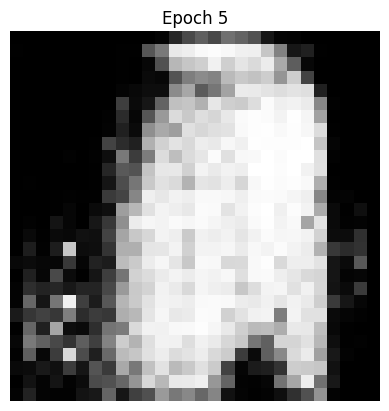

235/235 ━━━━━━━━━━━━━━━━━━━━ 28s 118ms/step - d_loss: 0.7188 - g_loss: 0.6709
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 28s 116ms/step - d_loss: 0.7225 - g_loss: 0.6488
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - d_loss: 0.7144 - g_loss: 0.6607
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - d_loss: 0.7048 - g_loss: 0.6729
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - d_loss: 0.7052 - g_loss: 0.6796
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - d_loss: 0.6995 - g_loss: 0.6766\nSaved generator model at epoch 10


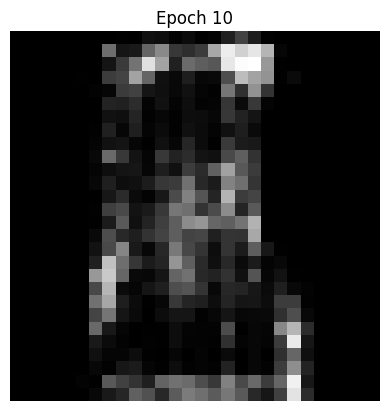

235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - d_loss: 0.6935 - g_loss: 0.6517
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - d_loss: 0.6799 - g_loss: 0.6423
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - d_loss: 0.7016 - g_loss: 0.6938
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - d_loss: 0.6868 - g_loss: 0.6900
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - d_loss: 0.6814 - g_loss: 0.6228
Epoch 15/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - d_loss: 0.6986 - g_loss: 0.6808

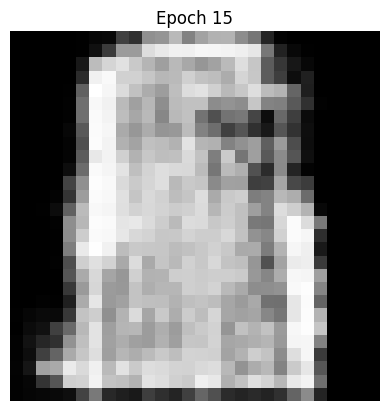

235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - d_loss: 0.6979 - g_loss: 0.6870
Epoch 16/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - d_loss: 0.6678 - g_loss: 0.6513
Epoch 17/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - d_loss: 0.6607 - g_loss: 0.6076
Epoch 18/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 28s 119ms/step - d_loss: 0.6210 - g_loss: 0.5660
Epoch 19/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 28s 118ms/step - d_loss: 0.6345 - g_loss: 0.5819
Epoch 20/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - d_loss: 0.6362 - g_loss: 0.7080\nSaved generator model at epoch 20


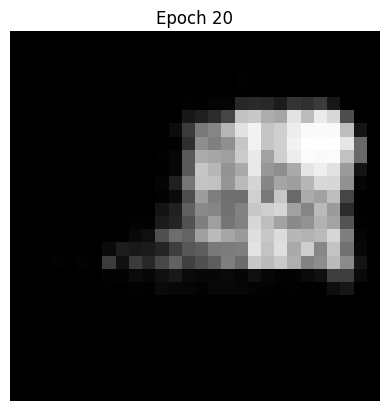

235/235 ━━━━━━━━━━━━━━━━━━━━ 28s 118ms/step - d_loss: 0.6333 - g_loss: 0.6821
Training complete and final model saved successfully.


In [8]:
discriminator = build_discriminator()
generator = build_generator(LATENT_DIM)

gan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=LATENT_DIM)

gan.compile(
    d_optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005, beta_1=0.5),
    g_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss_fn=tf.keras.losses.BinaryCrossentropy(),
)

class SaveModelAndImages(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            os.makedirs("models", exist_ok=True)
            
            self.model.generator.save(f"models/generator_epoch_{epoch+1}.keras")
            print(f"\\nSaved generator model at epoch {epoch+1}")

        if (epoch + 1) % 5 == 0:
            noise = tf.random.normal([1, LATENT_DIM])
            gen_image = self.model.generator(noise, training=False)
            plt.imshow(gen_image[0, :, :, 0] * 127.5 + 127.5, cmap="gray")
            plt.title(f"Epoch {epoch+1}")
            plt.axis("off")
            plt.show()


EPOCHS = 20
gan.fit(dataset, epochs=EPOCHS, callbacks=[SaveModelAndImages()])

generator.save("models/final_generator_model.keras")
print("Training complete and final model saved successfully.")


Predictions


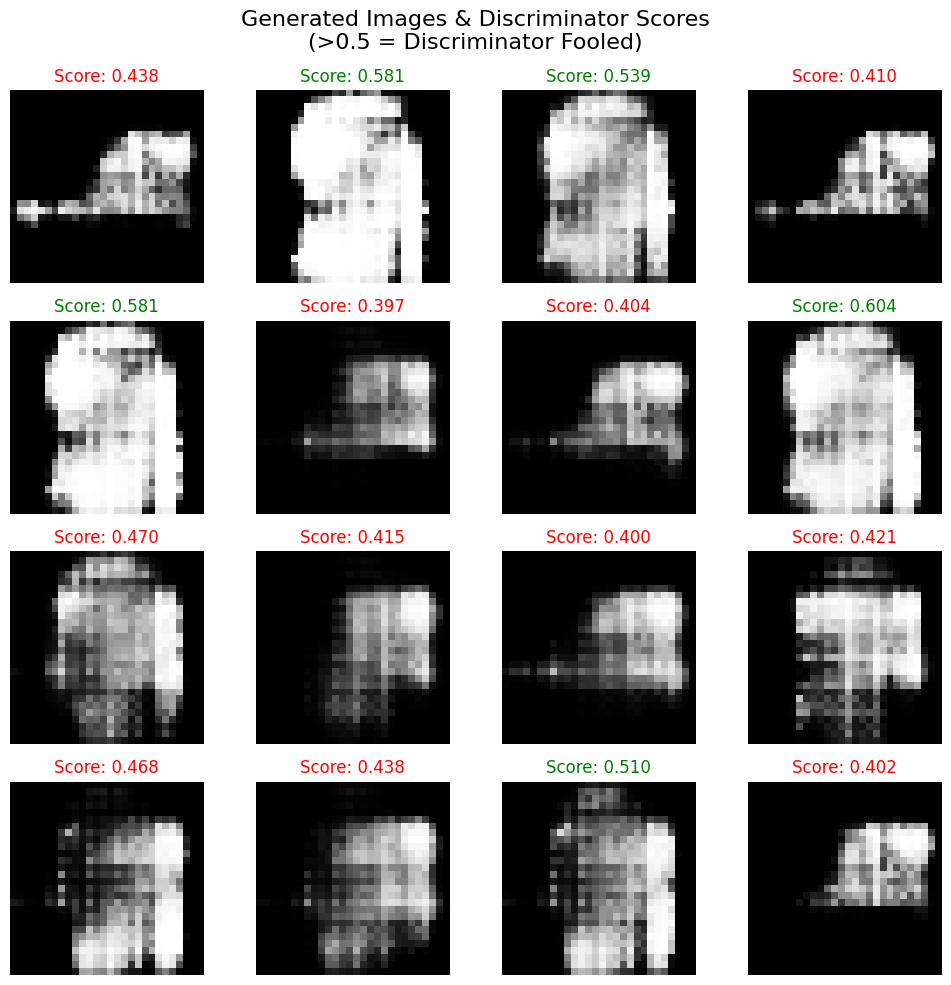

In [9]:
test_and_predict(generator, discriminator, LATENT_DIM)